In [345]:
# Importa a biblioteca Pandas, utilizada para manipulação, tratamento e análise de dados em DataFrames
import pandas as pd

# Importa a função responsável por dividir os dados em conjuntos de treinamento e teste para avaliação de modelo
from sklearn.model_selection import train_test_split

# Importa a classe StandardScaler, utilizada para padronizar variáveis numéricas em uma mesma escala
from sklearn.preprocessing import StandardScaler

# Importa o modelo de Regressão Linear, utilizada para prever valores numéricos a partir da relação entre X e y
from sklearn.linear_model import LinearRegression

# Importa métricas para avaliar a qualidade das previsões do modelo
# 'mean_squared_error' é o quanto o modelo errou
# 'r2_score' é o quão bem o modelo explicou os dados
# 'mean_absolute_error' mede o erro médio absoluto das previsões
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Importa o módulo pyplot da biblioteca Matplotlib, utilizado para criar gráficos e visualizações de dados
import matplotlib.pyplot as plt

In [346]:
# Importa a tabela de dados para regressão linear
dados = pd.read_excel('../data/dados-regressao-linear.xlsx')

In [347]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


In [348]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [349]:
# Verifica quais valores há na coluna informada
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?
Empregado (CLT)                                                    2762
Empreendedor ou Empregado (CNPJ)                                    410
Desempregado, buscando recolocação                                  350
Estagiário                                                          188
Servidor Público                                                    156
Trabalho na área Acadêmica/Pesquisador                               86
Somente Estudante (graduação)                                        82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil      69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil        46
Somente Estudante (pós-graduação)                                    44
Freelancer                                                           39
Prefiro não informar                                                 24
Desempregado e não estou buscando recolocação                        15
Name: count, dtype: int64

In [350]:
# Filtra, na coluna 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', apenas quem é 'Empregado (CLT)'
dados = dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'] == 'Empregado (CLT)']

In [351]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?
Empregado (CLT)    2762
Name: count, dtype: int64

In [352]:
dados['COR/RACA/ETNIA'].value_counts()

COR/RACA/ETNIA
Branca                  1805
Parda                    661
Preta                    181
Amarela                   85
Prefiro não informar      16
Outra                     10
Indígena                   4
Name: count, dtype: int64

In [353]:
# Como os valores 'Prefiro não informar', 'Outra' e 'Indígena' representam bem pouco na tabela
# e, considerando que esses valores podem trazer um resultado não desejado, é melhor excluí-los
categorias_excluidas = ['Prefiro não informar', 'Outra', 'Indígena']

In [354]:
# Filtra o DataFrame, removendo os registros cuja 'COR/RECA/ETNIA' esteja na lista de categorias que não serão analisadas
# .isin() verifica cada valor da coluna e se ele está na lista de categorias que se deseja excluir
# ~ inverte o resultado, selecionando apenas os registros que NÃO estão na lista
dados = dados[~dados['COR/RACA/ETNIA'].isin(categorias_excluidas)]

In [355]:
# Cria uma nova coluna chamada 'NAO_BRANCA'
# O Pandas compara cada valor da coluna com 'Branca' e gera uma série de valores booleanos (True/False)
# - se a categoria for diferente de 'Branca' é True | se a categoria for 'Branca' é False
# .astype(int) converte True para 1 e False para 0
# Resultado: 1 = Pessoa não branca | 0 = Pessoa branca
dados['NAO_BRANCA'] = (dados['COR/RACA/ETNIA'] != 'Branca').astype(int)

In [356]:
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts()

QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?
de 1 a 2 anos                             743
de 3 a 4 anos                             584
de 4 a 6 anos                             416
Menos de 1 ano                            353
Mais de 10 anos                           277
de 7 a 10 anos                            232
Não tenho experiência na área de dados    127
Name: count, dtype: int64

In [357]:
# Acessa a coluna 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'
# Usa .str.extract() para extrair o primeiro trecho que corresponde ao padrão informado
# A regex r'(\d+)' procura uma sequência de um ou mais dígitos dentro do texto, de 0 a 9, e retorna apenas esse valor
# Exemplo: '1 ano' -> '1' | '15 anos' -> '15' 
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')

In [358]:
dados['TEMPO_EXPERIENCIA'].value_counts()

TEMPO_EXPERIENCIA
1     1096
3      584
4      416
10     277
7      232
Name: count, dtype: int64

In [359]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

NUMERO DE FUNCIONARIOS
Acima de 3.000      1313
de 101 a 500         503
de 1.001 a 3.000     368
de 501 a 1.000       248
de 51 a 100          146
de 11 a 50           112
de 6 a 10             24
de 1 a 5              18
Name: count, dtype: int64

In [360]:
# Remove os pontos da coluna 'NUMERO DE FUNCIONARIOS'
# É importante essa remoção para converter depois a coluna para um tipo numérico
# Nas versões atuais do Pandas, o ponto (.) pode ser interpretado como expressão regular (regex), significando 'qualquer caractere'
dados['NUMERO DE FUNCIONARIOS'] = (
    dados['NUMERO DE FUNCIONARIOS']
    .str.replace('.', '', regex=False)
)

In [361]:
# Os valores não possuem mais o ponto (.)
dados['NUMERO DE FUNCIONARIOS'].value_counts()

NUMERO DE FUNCIONARIOS
Acima de 3000     1313
de 101 a 500       503
de 1001 a 3000     368
de 501 a 1000      248
de 51 a 100        146
de 11 a 50         112
de 6 a 10           24
de 1 a 5            18
Name: count, dtype: int64

In [362]:
# Extrai o primeiro número presente em cada faixa, transformando as respostas como:
# 'de 101 a 500' -> 101
# 'Acima de 3.000' -> 3000
dados['NUMERO DE FUNCIONARIOS'] = (
    dados['NUMERO DE FUNCIONARIOS']
    .str.extract(r'(\d+)')
)

In [363]:
# Mostra os valores da coluna 'NUMERO DE FUNCIONARIOS', incluindo os valores nulos (NaN)
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

NUMERO DE FUNCIONARIOS
3000    1313
101      503
1001     368
501      248
51       146
11       112
6         24
1         18
Name: count, dtype: int64

In [364]:
# Os nulos são frutos do valor 'Não tenho experiência na área de dados', logo podemos usar como o '0' como valor
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

TEMPO_EXPERIENCIA
1      1096
3       584
4       416
10      277
7       232
NaN     127
Name: count, dtype: int64

In [365]:
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0)

In [366]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

TEMPO_EXPERIENCIA
1     1096
3      584
4      416
10     277
7      232
0      127
Name: count, dtype: int64

In [367]:
# Para entender quais motivos aparecem quanto à insatisfação com a empresa atual
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts()

Qual o principal motivo da sua insatisfação com a empresa atual?
Gostaria de trabalhar em em outra área de atuação                                                                                                           69
Salário atual não corresponde ao mercado                                                                                                                    53
Falta de oportunidade de crescimento no emprego atual                                                                                                       46
Falta de maturidade analítica na empresa                                                                                                                    45
Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa                   26
                                                                                                                                            

In [368]:
# Cria uma nova coluna com valores iguais a 0
dados['INSATISFACAO'] = 0

In [369]:
# Exibe a coluna indicada e seus valores (que estão zerados após o código de cima)
dados['INSATISFACAO'].value_counts()

INSATISFACAO
0    2732
Name: count, dtype: int64

In [370]:
# Filtra apenas os registros que responderam à pergunta com .notnull()

# O loc[] é utilizado para:
# - Lado esquerdo: indicar onde os valores serão gravados
#   (linhas com resposta da pergunta e coluna 'INSATISFACAO')
# - Lado direito: selecionar os textos que serão analisados
#   (linhas com resposta da pergunta e coluna da pergunta)

# O apply() percorre cada resposta e a função lambda verifica se a palavra 'Salário' está presente no texto:
# - 1 = salário foi citado como motivo de insatisfação
# - 0 = salário não foi citado

# A coluna 'INSATISFACAO' passa a funcionar como uma variável binária (True/False)

dados.loc[
    dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(),
    'INSATISFACAO'      
] = dados.loc[
    dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(),
    'Qual o principal motivo da sua insatisfação com a empresa atual?'
].apply(lambda x: 1 if 'Salário' in x else 0)

In [371]:
# 0 = pessoas que não citaram 'Salário' em sua resposta
# 1 = pessoas que citaram 'Salário' em sua resposta
dados['INSATISFACAO'].value_counts()

INSATISFACAO
0    2453
1     279
Name: count, dtype: int64

In [372]:
dados['NIVEL DE ENSINO'].value_counts()

NIVEL DE ENSINO
Graduação/Bacharelado         1024
Pós-graduação                  975
Mestrado                       306
Estudante de Graduação         271
Doutorado ou Phd               100
Não tenho graduação formal      52
Prefiro não informar             4
Name: count, dtype: int64

In [373]:
# Transforma a variável categórica ('NIVEL DE ENSINO') em uma variável numérica ordinal
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(
    lambda x:
    0 if x == 'Não tenho graduação formal' else
    1 if x == 'Estudante de Graduação' else
    2 if x == 'Graduação/Bacharelado' else
    3 if x == 'Pós-graduação' else
    4 if x == 'Mestrado' else
    5 if x == 'Doutorado ou Phd' else -1
)

In [374]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [375]:
# Seleciona as colunas que serão utilizadas para o modelo
dados = dados[
    [
        'IDADE',
        'GENERO',
        'NAO_BRANCA',
        'TEMPO_EXPERIENCIA',
        'INSATISFACAO',
        'SETOR',
        'REGIAO ONDE MORA',
        'NIVEL DE ENSINO',
        'NUMERO DE FUNCIONARIOS',
        'SALARIO',
        'NOVO_NIVEL'
    ]
]

In [376]:
dados.columns

Index(['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL'],
      dtype='object')

In [377]:
# O método 'pd.get_dummies()' transforma variáveis categóricas (texto) em variáveis numéricas binárias (0 e 1)
# Esse processo é conhecido por One-Hot Encoding e utilizado na preparação de dados para análise e modelo de Machine Learning
# Para cada categoria encontrada, é criada uma nova coluna
# O parâmetro 'drop_first=True' remove uma das categorias de cada coluna, evitando duplicidade de informações
dados = pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True)

Nesse ponto, o conjunto de dados será separado em 2:
- conjunto de treinamento, utilizado pelo modelo para aprender
- conjunto de teste, utilizado para avaliar o desempenho do modelo para os dados que o modelo ainda não viu

In [378]:
# Separa os dados em variáveis independentes (X) e variável alvo (y)
# X contém todas as características que serão utilizadas pelo modelo para realizar previsões
# y contém a variável que o modelo deve aprender a prever: 'SALARIO'
# axis=1 indica que a coluna 'SALARIO' será removida do DataFrame
X = dados.drop('SALARIO', axis=1)
y = dados['SALARIO']

In [379]:
# Divide os dados em conjunto de treinamento e teste
# X contém variáveis independentes (características utilizadas pelo modelo)
# y contém a variável alvo (valor que o modelo deve aprender a prever)
# 'test_size=0.2' reserva 20% dos dados para teste e utiliza 80% para treinamento
# 'random_state=42' fixa a aleatoriedade da divisão, garantindo que o resultado seja o mesmo sempre que o código for executado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [380]:
# Cria uma instância do StandardScaler, responsável por padronizar as variáveis numéricas para uma mesma escala
scaler = StandardScaler()

# Aprende a média e o desvio padrão dos dados de treinamento (fit) e aplica a padronização (transform)
X_train_scaled = scaler.fit_transform(X_train)

# Aplica aos dados de teste a mesma padronização aprendida nos dados de treinamento, sem recalcular média e desvio padrão
# Isso garante que treino e teste utilizem a mesma escala
X_test_scaled = scaler.transform(X_test)

In [381]:
# Cria uma instância do modelo de Regressão Linear
# Nesse momento, o modelo é apenas incializados e ainda não possui nenhum conhecimento sobre os dados
model = LinearRegression()

In [382]:
# Treina o modelo utilizando os dados de treinamento padronizados (X_train_scaled) e os valores reais da variável alvo (y_train)
# Ele faz uma equação capaz de realizar previsões
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](35,)","[-133.03,-423.4 ,2004.02,...,-256.25,-201.49,-576.23]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.013e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,35
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,35
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](35,)","[66.32,62.55,55.44,...,22.11,13.6 , 6.75]"


In [383]:
# Realiza previsões utilizando os dados de teste e armazena na variável 'y_pred'
y_pred = model.predict(X_test_scaled)

In [384]:
# Calcula o Erro Quadrado Médio entre os valores reais (y_test) e os valores previstos pelo modelo (y_pred)
# Quanto menor o MSE, melhor o desempenho do modelo, pois isso indica que as previsões estão próximos dos valores reais
mse = mean_squared_error(y_test, y_pred)
mse

23235667.570491776

- O resultado, à primeira vista, parece um número muito alto, mas isso é normal porque o MSE eleva os erros ao quadrado.
- Por isso, muitas vezes também se calcula a Raiz do Erro Quadrático Médio (RMSE).

In [385]:
# Calcula o Erro Absoluto Médio (MAE) entre os valores reais (y_test) e os valores previstos pelo modelo (y_pred)
# Quanto menor o MAE, melhor o desempenho do modelo
mae = mean_absolute_error(y_test, y_pred)
mae

3324.5922372701402

In [386]:
# Calcula o coeficiente de determinação (R²) do modelo
# R² mede o quanto o modelo consegue explicar a variação dos dados da variável alvo
# Quanto mais próximo de 1, melhor o desempenho do modelo
# Interpretação geral:
# R² = 1   -> ajuste perfeito
# R² = 0   -> modelo não explica a variação dos dados
# R² < 0   -> desempenho pior que uma previsão simples pela média
r2 = r2_score(y_test, y_pred)
r2

0.5259207659570251

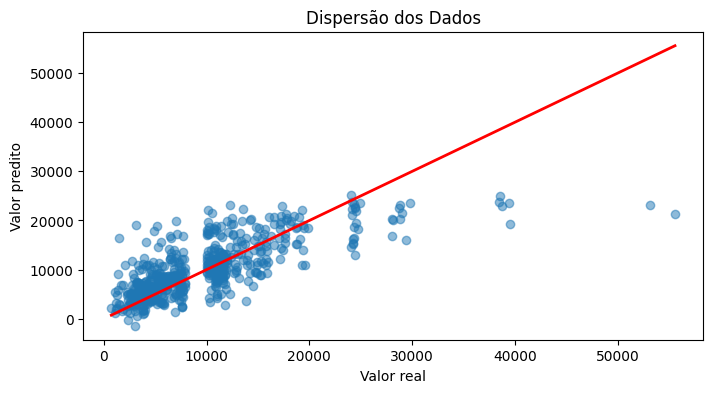

In [388]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Valor real')
plt.ylabel('Valor predito')
plt.title('Dispersão dos Dados')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.show()

In [ ]:
# Obtém os nomes das variáveis utilizadas no treinamento do modelo e armazena na variável 'nomes_atributos'
nomes_atributos = X_train.columns
nomes_atributos

Index(['IDADE', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria', 'NOVO_NIVEL_Pessoa Gestora',
       'NOVO_NIVEL_Pleno', 'NOVO_NIVEL_Sênior', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul'],
      dtype='object')

In [ ]:
# Cria uma tabela que relaciona cada variável ao seu coeficiente na Regressão Linear e armazena na variável 'coeficiente'
# Isso facilita a interpretação da infulência de cada variável nas previsões do modelo
coeficiente = pd.DataFrame(model.coef_, columns=['coeficientes'], index=nomes_atributos)

In [394]:
# Ordena os coeficientes do modelo em ordem decrescente
# Exibe primeiro as variáveis com maior influência positiva nas previsões da Regressão Linear
coeficiente = coeficiente.sort_values(by='coeficientes', ascending=False)

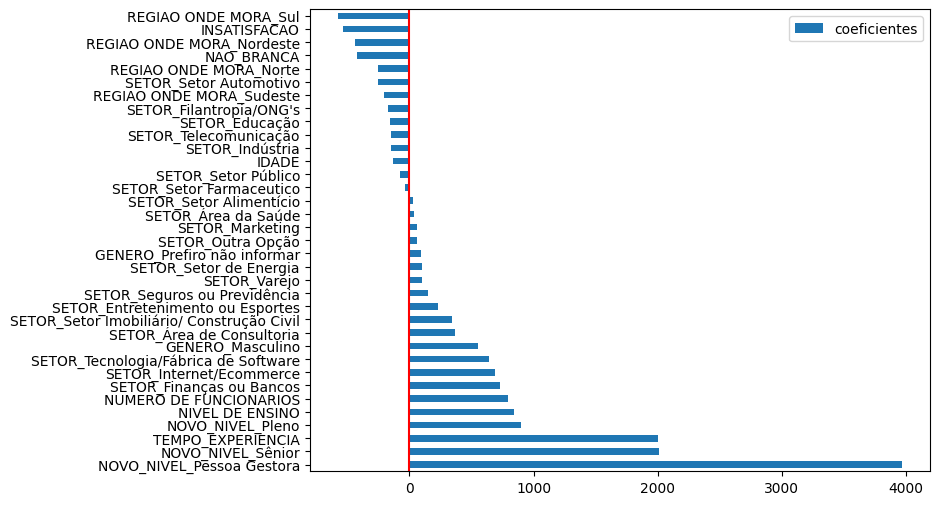

In [397]:
coeficiente.plot.barh(figsize=(8,6))
plt.axvline(x=0, color='red')

- O gráfico acima mostra os coeficientes da Regressão Linear para cada variável do modelo. Ou seja, ele mostra quais variáveis mais influenciam a previsão do salário e em qual direção essa inflência ocorre.
- A linha vermelha representa o zero. Barras à direta, coeficiente positivo, tendem a aumentar o salário previsto. Barras à esquerda, coeficiente negativo, tendem a reduzir o salário previsto. Barras próximas ao zero, pouca influência no modelo.

In [398]:
dados.to_csv('../data/regressao_linear_tratada.csv', index=False)